
**Importing the Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

**Load DataSet**

In [4]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Basic Info**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.shape

(891, 12)

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**EDA (Visualization)**

**1. Survival Count**

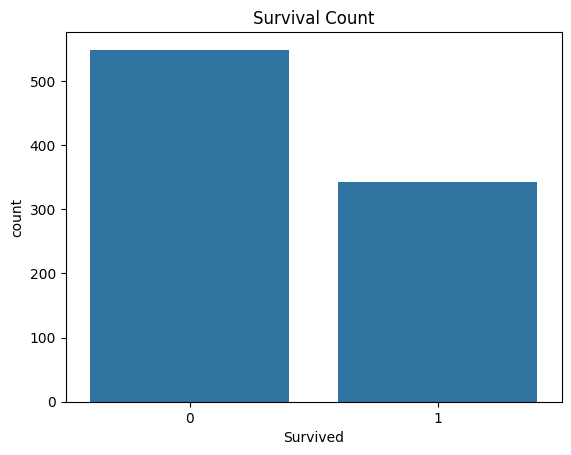

In [9]:
sns.countplot(x="Survived",data=df)
plt.title("Survival Count")
plt.show()

**2. Survival by Gender**

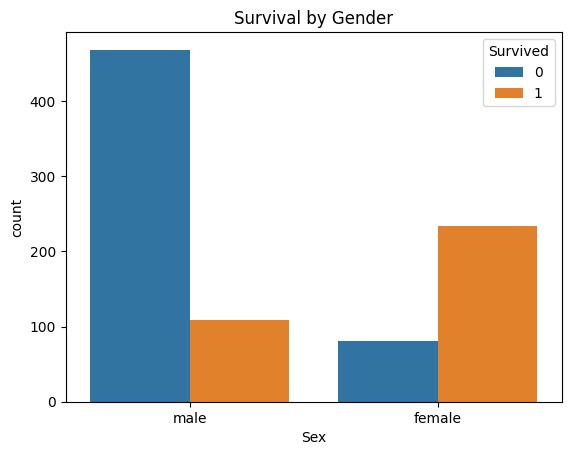

In [10]:
sns.countplot(x="Sex", hue="Survived",data=df)
plt.title("Survival by Gender")
plt.show()

**3. Survival by Class**

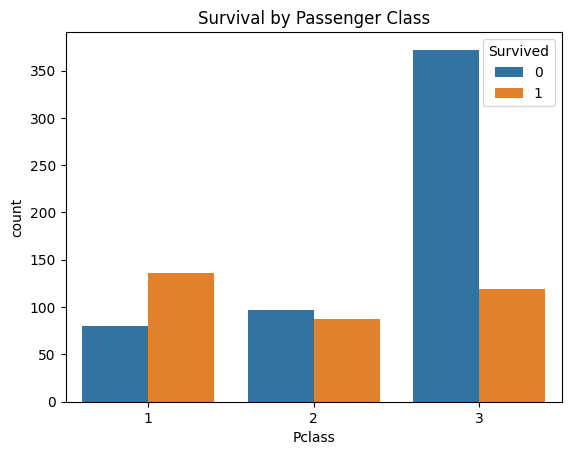

In [11]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

**4. Age** **Distribution**

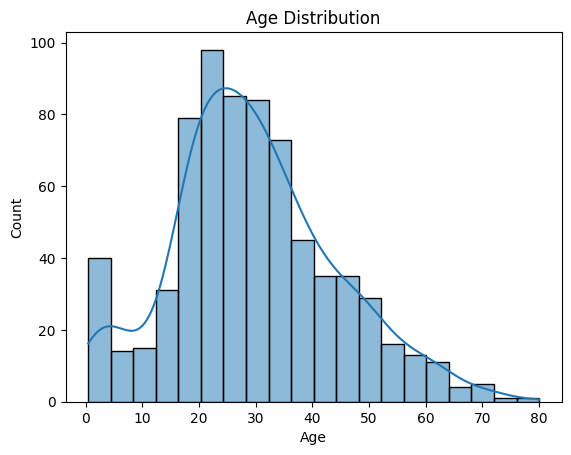

In [12]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

**Feature Engineering**

In [13]:
#Drop useless columns
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [14]:
# Handling Missing value
df["Age"].fillna(df["Age"].median(),inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0] , inplace=True)

In [15]:
#Convert categorical to numeric
df['Sex']=df['Sex'].map({'male': 0 , 'female': 1})
df = pd.get_dummies(df , columns=['Embarked'], drop_first=True)

In [16]:

# Create new feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = 1
df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0


**Model Training**

In [17]:
# Split data

from sklearn.model_selection import train_test_split

X=df.drop('Survived',axis=1)
y=df['Survived']

X_train,X_test, y_train,y_test = train_test_split(X,y , test_size=0.2 , random_state=42)


**Train Model**

**Logistic Regression**

In [18]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=100)
lr.fit(X_train,y_train)

LogisticRegression()

**Random Forest**

In [19]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

**Evaluation**

In [20]:
from sklearn.metrics import accuracy_score
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8044692737430168
Random Forest Accuracy: 0.8324022346368715


**ACCURACY COMPARISON**

In [21]:
from sklearn.metrics import accuracy_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.804469
1        Random Forest  0.832402


**OVERFITTING CHECK**

In [22]:
print("Random Forest Train Accuracy:", rf.score(X_train, y_train))
print("Random Forest Test Accuracy:", rf.score(X_test, y_test))

Random Forest Train Accuracy: 0.9789325842696629
Random Forest Test Accuracy: 0.8324022346368715


**Feature Importance**

In [23]:
import pandas as pd

importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(feat_imp)

      feature  importance
1         Sex    0.271105
5        Fare    0.262954
2         Age    0.248771
0      Pclass    0.077785
8  FamilySize    0.042982
3       SibSp    0.029954
7  Embarked_S    0.024830
4       Parch    0.020296
9     IsAlone    0.012035
6  Embarked_Q    0.009289


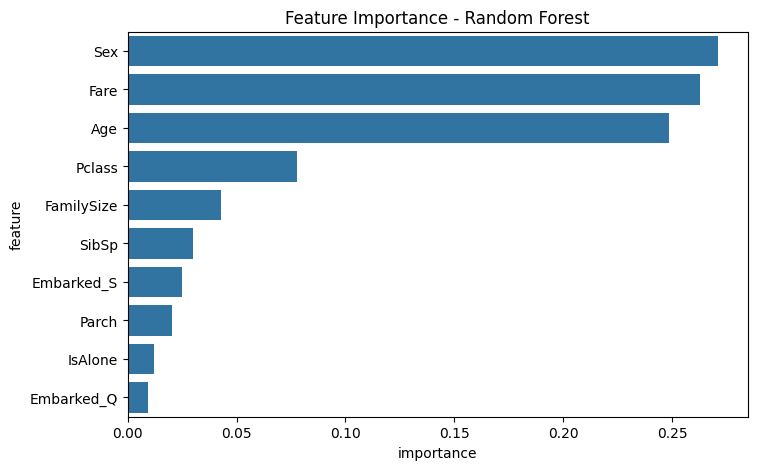

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x="importance", y="feature", data=feat_imp)
plt.title("Feature Importance - Random Forest")
plt.show()

**CONFUSION MATRIX**

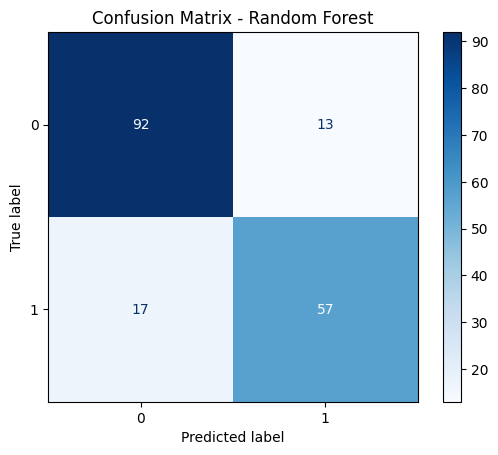

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

**Conclusion**

In this project, we analyzed the Titanic dataset and built machine learning models to predict passenger survival.

After data cleaning, feature engineering, and encoding categorical variables, we trained Logistic Regression and Random Forest models.

Random Forest achieved the highest accuracy (~83%), showing better performance in capturing non-linear relationships.

Feature importance analysis revealed that Sex, Fare, and Passenger Class were the most important factors in survival prediction.

This project demonstrates skills in data preprocessing, feature engineering, model building, evaluation, and visualization.

In [26]:
import pickle
pickle.dump(rf, open("titanic_model.pkl", "wb"))